## Importation des biblioteques

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
#from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
import numpy as p
from sklearn.utils import resample
from sklearn.svm import SVC
import mlflow.sklearn
import mlflow

## Importation du donnée qu'on va utiliser

In [2]:
data = pd.read_csv("../data/wine_fraud.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


### Information sur les colonnes

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   object 
 12  type                  6497 non-null   object 
dtypes: float64(11), object(2)
memory usage: 660.0+ KB


### Une petite resume statistique du data 

In [4]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


### Verification des données maquantes

In [5]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

### Verification de l'equilibre sur les classes

In [6]:
data["type"].value_counts()

type
white    4898
red      1599
Name: count, dtype: int64

In [7]:
data["quality"].value_counts()

quality
Legit    6251
Fraud     246
Name: count, dtype: int64

(array([6251.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         246.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

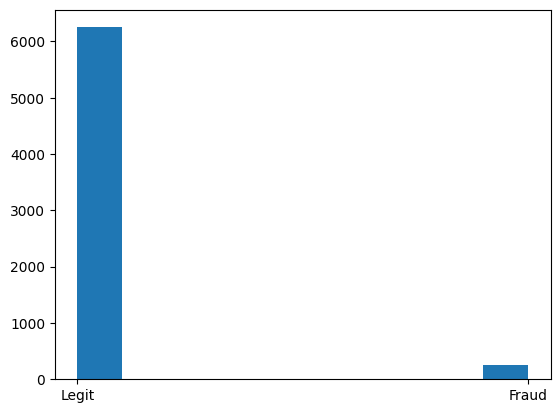

In [8]:
plt.hist(data["quality"])

### Reequilibre des classes

In [9]:
mi = data[data.quality == "Legit"]
ma = data[data.quality == "Fraud"]

ma_augmente = resample(ma, replace=True, n_samples=len(mi), random_state=42)

data_aug = pd.concat([mi, ma_augmente])
data_aug.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


(array([6251.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        6251.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

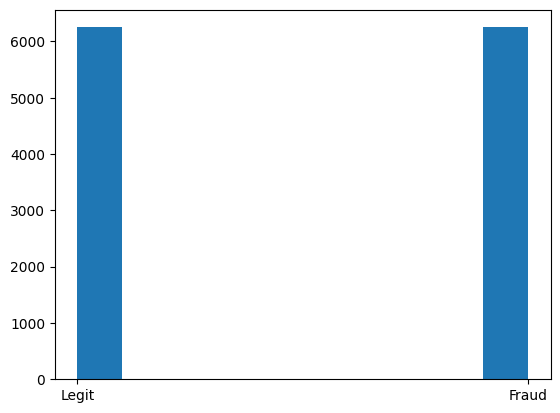

In [10]:
plt.hist(data_aug["quality"])


In [28]:
data_aug.to_csv("../data/wine_equilibre.csv")

In [11]:
df = data_aug.copy()

In [12]:
X = df.drop("quality", axis=1)
df["quality"] = df["quality"].apply(lambda x: 1 if x=="Legit" else 0)
y = df["quality"]

In [13]:
X["type"] = X["type"].apply(lambda x: 1 if x=="white" else 0)

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12502 entries, 0 to 2225
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         12502 non-null  float64
 1   volatile acidity      12502 non-null  float64
 2   citric acid           12502 non-null  float64
 3   residual sugar        12502 non-null  float64
 4   chlorides             12502 non-null  float64
 5   free sulfur dioxide   12502 non-null  float64
 6   total sulfur dioxide  12502 non-null  float64
 7   density               12502 non-null  float64
 8   pH                    12502 non-null  float64
 9   sulphates             12502 non-null  float64
 10  alcohol               12502 non-null  float64
 11  type                  12502 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 1.2 MB


In [15]:
X = X.rename(columns={
    "fixed acidity":"fixed_acidity",
    "volatile acidity":"volatile_acidity",
    "citric acid":"citric_acid",
    "residual sugar":"residual_sugar",
    "free sulfur dioxide":"free_sulfur_dioxide",
    "total sulfur dioxide":"total_sulfur_dioxide"
})
X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [16]:
num_cols = [col for col in X.columns if col != "type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", ["type"])
    ]
)

X_scaled = preprocessor.fit_transform(X)

In [18]:
import joblib

#joblib.dump(preprocessor, "../models/scaler1.pkl")

In [20]:
sc = joblib.load("../models/scaler1.pkl")
xc = sc.transform(X)

In [17]:
xc

array([[ 0.09425056,  1.35807503, -1.79675692, ...,  0.24492388,
        -0.84331837,  0.        ],
       [ 0.39934698,  2.17845399, -1.79675692, ...,  0.98885934,
        -0.48807933,  0.        ],
       [ 0.39934698,  1.63153468, -1.55592501, ...,  0.80287548,
        -0.48807933,  0.        ],
       ...,
       [-0.59221638,  2.17845399, -1.61613299, ..., -0.12704385,
         0.75525734,  0.        ],
       [ 1.92482906, -0.69287236,  2.65863352, ..., -0.5610062 ,
        -0.3104598 ,  1.        ],
       [ 0.24679877,  0.72000251, -1.07426118, ..., -0.43701696,
        -1.10974766,  1.        ]], shape=(12502, 12))

In [ ]:
X_scaled

array([[ 0.09425056,  1.35807503, -1.79675692, ...,  0.24492388,
        -0.84331837,  0.        ],
       [ 0.39934698,  2.17845399, -1.79675692, ...,  0.98885934,
        -0.48807933,  0.        ],
       [ 0.39934698,  1.63153468, -1.55592501, ...,  0.80287548,
        -0.48807933,  0.        ],
       ...,
       [-0.59221638,  2.17845399, -1.61613299, ..., -0.12704385,
         0.75525734,  0.        ],
       [ 1.92482906, -0.69287236,  2.65863352, ..., -0.5610062 ,
        -0.3104598 ,  1.        ],
       [ 0.24679877,  0.72000251, -1.07426118, ..., -0.43701696,
        -1.10974766,  1.        ]], shape=(12502, 12))

In [21]:
X_train, X_test, y_train, y_test = train_test_split(xc, y, test_size=0.25, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(9376, 12)
(9376,)
(3126, 12)
(3126,)


In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
model_lr.score(X_test, y_test)

0.7156110044785668

In [24]:
model_lr.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [25]:
y_pred = model_lr.predict(X_test)

In [26]:
print(accuracy_score(y_pred, y_test))
confusion_matrix(y_pred, y_test)

0.7156110044785668


array([[1029,  407],
       [ 482, 1208]])

In [27]:
model_svc = SVC()
model_svc.fit(X_train, y_train)
model_svc.score(X_test, y_test)

0.8694817658349329

In [28]:
y_pred_svc = model_svc.predict(X_test)

In [29]:
print(accuracy_score(y_pred_svc, y_test))
confusion_matrix(y_pred_svc, y_test)

0.8694817658349329


array([[1359,  256],
       [ 152, 1359]])

In [30]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)
model_rf.score(X_test, y_test)

0.9961612284069098

In [31]:
y_pred_rf = model_rf.predict(X_test)

In [32]:
print(accuracy_score(y_pred_rf, y_test))
confusion_matrix(y_pred_rf, y_test)

0.9961612284069098


array([[1511,   12],
       [   0, 1603]])

In [33]:
classification_report(y_pred_rf, y_test)

'              precision    recall  f1-score   support\n\n           0       1.00      0.99      1.00      1523\n           1       0.99      1.00      1.00      1603\n\n    accuracy                           1.00      3126\n   macro avg       1.00      1.00      1.00      3126\nweighted avg       1.00      1.00      1.00      3126\n'

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
model_dc = DecisionTreeClassifier()
model_dc.fit(X_train, y_train)
model_dc.score(X_test, y_test)

0.9865642994241842

In [36]:
y_pred_dc = model_dc.predict(X_test)

In [37]:
print(accuracy_score(y_pred_dc, y_test))
confusion_matrix(y_pred_dc, y_test)

0.9865642994241842


array([[1511,   42],
       [   0, 1573]])

In [38]:
classification_report(y_pred_dc, y_test)

'              precision    recall  f1-score   support\n\n           0       1.00      0.97      0.99      1553\n           1       0.97      1.00      0.99      1573\n\n    accuracy                           0.99      3126\n   macro avg       0.99      0.99      0.99      3126\nweighted avg       0.99      0.99      0.99      3126\n'

In [42]:
import joblib


joblib.dump(model_dc, "../models/model_dc.pkl")
joblib.dump(model_rf, "../models/model_rf.pkl")
joblib.dump(model_lr, "../models/model_lr.pkl")
joblib.dump(model_svc, "../models/model_svc.pkl")

['../models/model_svc.pkl']

In [43]:
mod = joblib.load("../models/model_dc.pkl")
print(type(mod))

<class 'sklearn.tree._classes.DecisionTreeClassifier'>
